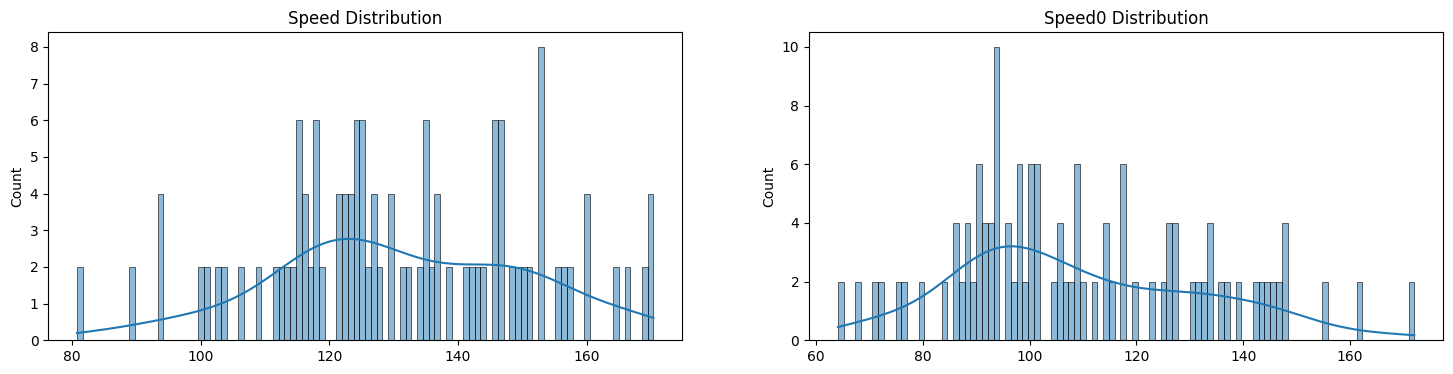

speed 131.14600039861892
speed0 109.23964076106981
ratio 1.2005348926903097
speed std 19.92030685338807
speed0 std 23.18279073121331


In [1]:
import json
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
##baseline vs eagle
# tokenizer=AutoTokenizer.from_pretrained("~/autodl-tmp/weights/hf/EAGLE3-LLaMA3.3-Instruct-70B/")
jsonl_file = "../output/mt_bench/llama3.1/t1d7/5090/llama38b2_40-temperature-1.0.jsonl"
jsonl_file_base = "../output/mt_bench/llama3.1/t1d7/5090/hass-speedtest-1.jsonl"
data = []
with open(jsonl_file, 'r', encoding='utf-8') as file:
    for line in file:
        json_obj = json.loads(line)
        data.append(json_obj)



speeds=[]
for datapoint in data:
    qid=datapoint["question_id"]
    for ch in datapoint["choices"]:
        answer=ch['turns']
        tokens=sum(ch['new_tokens'])
        times = sum(ch['wall_time'])
        speeds.append(tokens/times)
        # tokens = 0
        # for i in answer:
        #     tokens += (len(tokenizer(i).input_ids) - 1)
        times = sum(ch['wall_time'])
        speeds.append(tokens / times)
        

data = []
with open(jsonl_file_base, 'r', encoding='utf-8') as file:
    for line in file:
        json_obj = json.loads(line)
        data.append(json_obj)


# total_time=0
# total_token=0
speeds0=[]
for datapoint in data:
    qid=datapoint["question_id"]
    for ch in datapoint["choices"]:
        answer=ch['turns']
        tokens=sum(ch['new_tokens'])
        times = sum(ch['wall_time'])
        speeds0.append(tokens/times)
        # tokens = 0
        # for i in answer:
        #     tokens += (len(tokenizer(i).input_ids) - 1)
        # times = sum(ch['wall_time'])
        speeds0.append(tokens / times)

#show speed and speed0 's distribution
fig, axes = plt.subplots(1, 2, figsize=(18, 4))
sns.histplot(speeds, bins=100, kde=True, ax=axes[0])
axes[0].set_title('Speed Distribution')
sns.histplot(speeds0, bins=100, kde=True, ax=axes[1])
axes[1].set_title('Speed0 Distribution')
plt.show()

print('speed',np.array(speeds).mean())
print('speed0',np.array(speeds0).mean())
print("ratio",np.array(speeds).mean()/np.array(speeds0).mean())

# cal std
print('speed std',np.array(speeds).std())
print('speed0 std',np.array(speeds0).std())

